In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive
from pyiga import algebra_cy, ieti_cy, bspline_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

In [221]:
def LshapeAnullus(deg, N, k=1):
    kvs = 3*[2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),)]

    # define geometry
    geos = [
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4),
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4).rotate_2d(angle=np.pi/4),
        geometry.annulus(r1=1.0, r2=1.5, phi = np.pi/4).rotate_2d(angle=np.pi/4),
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    M.outer_boundaries[0].add((1,(0,0)))
    return M

In [222]:
M = LshapeAnullus(2,30)
M.h_refine({1:None});

IMap = ieti.IetiMapper(M, dir_data={0:0}, subspace='C0', elim=1)

setting up constraints took 0.006728649139404297 seconds.
Basis setup took 0.0016922950744628906 seconds


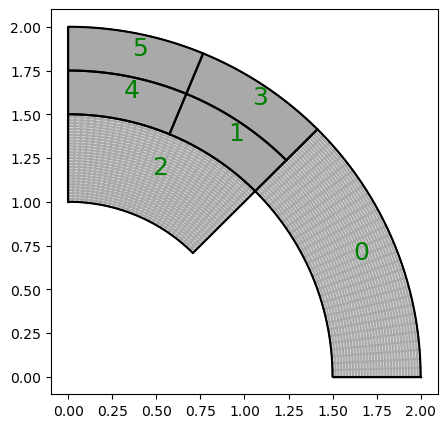

In [223]:
M.plotmesh(knots=1,patch_idx=1)

pcg with preconditioned condition number κ ~ 9.603 stopped after 15 iterations with relres 2.634e-09 after 0.0227 seconds.


<Axes: >

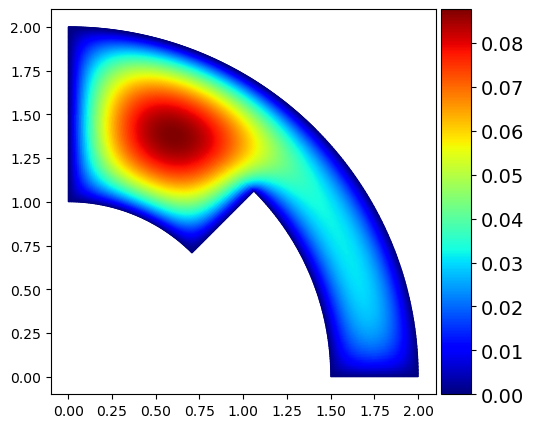

In [237]:
A, RHS = IMap.assemble(a=1,f=1, M=None)
N = [A.shape[0] for A in A]

Prim, to_be_eliminated = IMap.nodes_as_primals(dir_boundary=False)

B, eliminated_constraints = IMap.ConstraintMatrices(eliminate=to_be_eliminated)
SD = ieti.ScaledDirichletPreconditioner(A, B, IMap)

nPrim=Prim.shape[1]

if nPrim>0:
    primal = ieti.PrimalSystem(Prim)
    modA, modB, modRHS, C = primal.incorporate_PrimalConstraints(A, B, RHS, IMap)
    
    loc_solver = primal.compute_PrimalBasis(modA, modB, modRHS, C)
            
    modA.append(primal.A_prim), modB.append(primal.B_prim), modRHS.append(primal.RHS_prim)
    loc_solver.append(solvers.make_solver(primal.A_prim, spd=True, symm=True)), N.append(primal.A_prim.shape[0])
            
    I = ieti.IetiSystem(modA, modB, modRHS, N, loc_solver)
    F, b = I.SchurComplement(), I.RHSforSchurComplement()
else:
    I = ieti.IetiSystem(A, B, RHS, N)
    F, b = I.SchurComplement(), I.RHSforSchurComplement()
    C = [scipy.sparse.csr_matrix((0,A[p].shape[1])) for p in range(len(B))]

SD.setupConstraintScaling()
#SD.setupSelectionScaling()

P = SD.AsOperator()

lam, it, min_eig, max_eig, r = solvers.pcg(F, b, x0=None, maxiter=2000, P=P, output=1, rtol=1e-8, atol=1e-12)
uh = I.constructSolutionFromLagrangeMultipliers(lam)

if nPrim>0:
    uh = primal.distributePrimalSolution(uh)
uh = np.concatenate(IMap.completeDirichlet(uh))

IMap.plot(uh)


In [233]:
nPrim

5

In [234]:
SD.D[1]

array([0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.5    , 0.33333])

In [173]:
SD.B_full.toarray()

array([[ 0.,  0.,  0.,  1.,  0.,  0., -1.,  0.],
       [ 0.,  0.,  0.,  0.,  1.,  0.,  0., -1.]])

In [175]:
d = ieti_cy.pyx_constraint_scaling(SD.B_full.indptr, SD.B_full.indices, SD.B_full.data, *SD.B_full.shape)

In [176]:
d

array([1. , 1. , 1. , 0.5, 0.5, 1. , 0.5, 0.5])

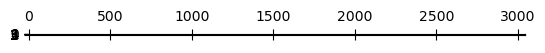

In [159]:
plt.spy(IMap.B[to_be_eliminated,:].toarray())

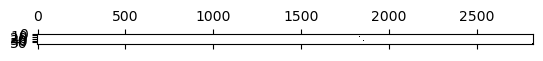

In [160]:
plt.spy(scipy.sparse.hstack(B).toarray())

In [112]:
to_be_eliminated

array([False, False,  True,  True,  True,  True,  True, False,  True, False, False, False,  True,  True, False, False,  True,  True, False, False, False,  True,  True, False, False,  True,  True, False,  True,  True])

In [119]:
SD.D

[array([0.33333, 0.33333]), array([1. , 0.5, 0.5]), array([-1., inf, inf])]

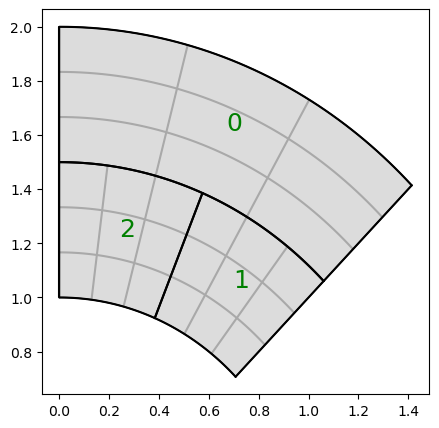

In [122]:
IMap.mesh.plotmesh(knots=1,patch_idx=1)

In [83]:
IMap.N_ofs_elim

array([ 0,  9, 18], dtype=int32)

In [78]:
IMap.Basis_loc_global.toarray()

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 

In [67]:
operators.make_solver(A[1])@RHS[1]

array([0.03655, 0.02951])

In [79]:
IMap.Basis_loc[1]@IMap.BCRestr[1].complete(operators.make_solver(A[1])@RHS[1])

array([0.     , 0.02951, 0.     , 0.     , 0.03655, 0.     , 0.     , 0.     , 0.     ])

In [71]:
IMap.Basis_loc[1]

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 9 stored elements and shape (9, 9)>

In [65]:
IMap.BCRestr[1]

In [6]:
(IMap.B@scipy.sparse.block_diag(IMap.Basis_loc)).data

array([-1.,  1., -1.,  1., -1.,  1., -1.,  1.])

In [8]:
scipy.sparse.block_diag(IMap.Basis_loc).toarray()

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [69]:
IMap.Basis_loc

[<Compressed Sparse Column sparse matrix of dtype 'float64'
 	with 121 stored elements and shape (121, 121)>,
 <Compressed Sparse Column sparse matrix of dtype 'float64'
 	with 121 stored elements and shape (121, 121)>]

In [67]:
IMap.B@uh

array([0.     , 0.01174, 0.02064, 0.02681, 0.03033, 0.03129, 0.02976, 0.0258 , 0.01949, 0.01087, 0.     ])

In [ ]:


IMap.B[:,IMap.corners].toarray()

In [12]:
n = IMap.B.shape[1]
q = np.where(IMap.B.getnnz(0)>1)[0]
R = scipy.sparse.coo_matrix((np.ones(len(q)),(np.arange(len(q)),q)),shape=(len(q),n)).tocsr()
c_B = IMap.B@R.T
c_B.eliminate_zeros()

In [21]:
IMap.B.getnnz(0)>1

array([False, False, False, False, False, False, False, False, False, False, False, False, False,  True, False, False, False, False, False, False, False, False, False, False, False, False, False])

In [30]:
IMap.CornerConstr

array([ True, False,  True,  True, False,  True])

In [23]:
CornerConstr = IMap.B[:,IMap.corners]

array([[ 0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0., -1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0., -1.],
       [ 0.,  0.,  1.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  1.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  0.]])

In [27]:
IMap.B[:,IMap.corners].getnnz(1)>1

array([ True, False,  True,  True, False,  True])

In [15]:
Basis , _ = algebra_cy.pyx_compute_basis(c_B.shape[0], c_B.shape[1], c_B, maxiter=100, switch=0)

In [16]:
Basis

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1 stored elements and shape (1, 1)>

In [24]:
B[0].toarray()

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 1.],
       [0., 0.]])

In [26]:
IMap.B.toarray()

array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]])

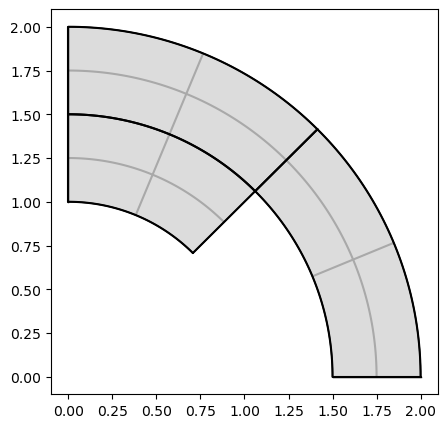

In [22]:
M.plotmesh(knots=1)